# V13 – Aufgaben: Musterlösungen

Vollständig gelöste Version aller fünf Aufgaben aus `../03_aufgaben.ipynb`. Die Testdaten-CSV liegt eine Ebene über diesem Ordner: `../lager_vibrationsdaten.csv`.

## 🎯 Überblick
1. CNC-Werkzeugverschleiß visualisieren (⭐)
2. Hydraulikdruck-Mittelwert (⭐)
3. Produktionsqualitäts-Kategorisierung (⭐)
4. FEM-Spannungen skalieren (⭐⭐)
5. Lager-Schwingungs-Analyse aus CSV (⭐⭐)


In [1]:
import matplotlib.pyplot as plt
import csv
import os

# Pfad zur CSV – eine Ebene höher, weil Lösungen im Unterordner liegen.
CSV_PFAD = "../lager_vibrationsdaten.csv"
print("CSV vorhanden:", os.path.exists(CSV_PFAD))


CSV vorhanden: True


## Aufgabe 1 ⭐ – Lösung

Direkter Aufruf von `plt.bar` mit allen drei Beschriftungen.


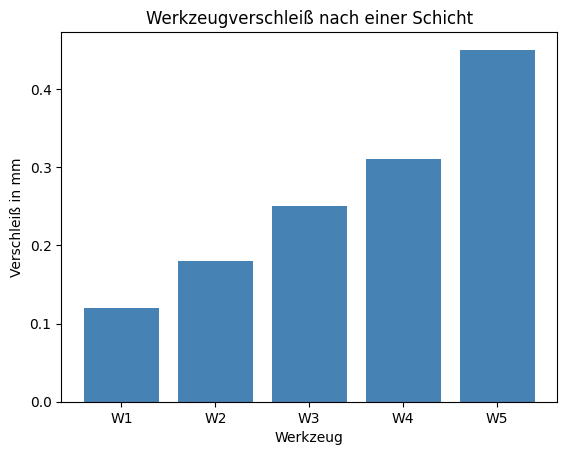

✅ A1: 5 Werkzeuge, max = 0.45 mm


In [2]:
import matplotlib.pyplot as plt

werkzeuge = ["W1", "W2", "W3", "W4", "W5"]
verschleiss = [0.12, 0.18, 0.25, 0.31, 0.45]

plt.figure()
plt.bar(werkzeuge, verschleiss, color="steelblue")
plt.title("Werkzeugverschleiß nach einer Schicht")
plt.xlabel("Werkzeug")
plt.ylabel("Verschleiß in mm")
plt.show()

print("✅ A1: 5 Werkzeuge, max =", max(verschleiss), "mm")


## Aufgabe 2 ⭐ – Lösung

Der Mittelwert ist `sum(liste) / len(liste)`. Bei leerer Liste würde `len == 0` zu einer `ZeroDivisionError` führen – in der Aufgabe nicht relevant, in der Lösung aber kurz abgefangen.


In [3]:
def mittelwert(liste):
    if len(liste) == 0:
        return 0.0
    return sum(liste) / len(liste)

drucke = [180, 190, 175, 185, 195, 182]
print("Mittelwert =", mittelwert(drucke), "bar")
assert abs(mittelwert(drucke) - 184.5) < 0.01
print("✅ A2 gelöst.")


Mittelwert = 184.5 bar
✅ A2 gelöst.


## Aufgabe 3 ⭐ – Lösung

Klassische mehrstufige `if` / `elif` / `else`-Kette. Entscheidend ist die **Reihenfolge** – von klein nach groß abfragen und mit `else` den Rest abdecken.


In [4]:
def kategorie(rate):
    if rate < 2:
        return "E1"
    elif rate < 5:
        return "E2"
    elif rate < 10:
        return "E3"
    else:
        return "E4"

for r, erwartet in [(0.5, "E1"), (1.99, "E1"), (2.0, "E2"),
                    (4.9, "E2"), (5.0, "E3"), (9.9, "E3"),
                    (10.0, "E4"), (25.0, "E4")]:
    assert kategorie(r) == erwartet, f"Fehler bei rate={r}"
print("✅ A3 gelöst – alle Kategorien korrekt.")


✅ A3 gelöst – alle Kategorien korrekt.


## Aufgabe 4 ⭐⭐ – Lösung

Eine List Comprehension baut die neue Liste: jedes Element mit `faktor` multiplizieren und mit `round(..., 2)` auf zwei Nachkommastellen runden. Alternativ ginge auch eine klassische `for`-Schleife mit `liste.append(...)`.


In [5]:
def spannungen_skaliert(werte, faktor):
    return [round(w * faktor, 2) for w in werte]

werte = [100.0, 150.5, 200.25, 180.1]
erg = spannungen_skaliert(werte, 1.5)
print("Skaliert:", erg)
assert erg == [150.0, 225.75, 300.38, 270.15]
assert spannungen_skaliert([10.0, 20.0], 2.0) == [20.0, 40.0]
assert spannungen_skaliert([1.234, 5.678], 1.0) == [1.23, 5.68]
print("✅ A4 gelöst.")


Skaliert: [150.0, 225.75, 300.38, 270.15]
✅ A4 gelöst.


## Aufgabe 5 ⭐⭐ – Lösung

Die CSV wird mit `csv.reader` gelesen, die Kopfzeile mit `next(reader)` übersprungen, die Amplitude-Spalte (`zeile[2]`) in eine Liste von `float` übernommen. Anschließend werden min, max und Mittelwert gebildet und jeweils auf zwei Stellen gerundet. Nachfolgend wird das Ergebnis zusätzlich als Balkendiagramm dargestellt.


Statistik: {'min': 0.18, 'max': 12.18, 'mittelwert': 2.98}


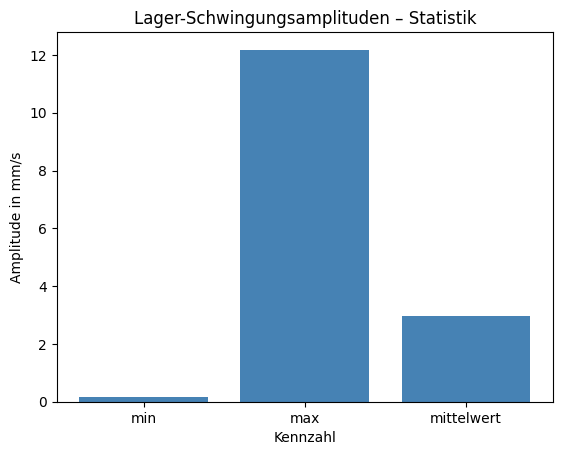

✅ A5 gelöst. Referenzwerte: {'min': 0.18, 'max': 12.18, 'mittelwert': 2.98}


In [6]:
import csv
import matplotlib.pyplot as plt

def amplituden_statistik(pfad):
    with open(pfad, encoding="utf-8") as f:
        reader = csv.reader(f)
        next(reader)  # Kopfzeile überspringen
        amplituden = [float(zeile[2]) for zeile in reader if zeile]
    return {
        "min": round(min(amplituden), 2),
        "max": round(max(amplituden), 2),
        "mittelwert": round(sum(amplituden) / len(amplituden), 2),
    }

erg = amplituden_statistik("../lager_vibrationsdaten.csv")
print("Statistik:", erg)

# Visualisierung als Balkendiagramm
plt.figure()
plt.bar(list(erg.keys()), list(erg.values()), color="steelblue")
plt.title("Lager-Schwingungsamplituden – Statistik")
plt.xlabel("Kennzahl")
plt.ylabel("Amplitude in mm/s")
plt.show()

# Re-Validierung gegen unabhängige Berechnung
with open("../lager_vibrationsdaten.csv", encoding="utf-8") as _f:
    _reader = csv.reader(_f)
    next(_reader)
    _amps = [float(z[2]) for z in _reader if z]
_erw = {
    "min": round(min(_amps), 2),
    "max": round(max(_amps), 2),
    "mittelwert": round(sum(_amps) / len(_amps), 2),
}
assert erg == _erw, f"Mismatch: {erg} vs {_erw}"
print("✅ A5 gelöst. Referenzwerte:", _erw)
